## Install necessary libraries 


In [79]:
%pip install yfinance matplotlib

Note: you may need to restart the kernel to use updated packages.


In [80]:
%pip install tensorflow-macos tensorflow-metal

Note: you may need to restart the kernel to use updated packages.


## Import Libraries

In [81]:

import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from keras import Model
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential


## Download Stock Data from Yahoo Finance

In [82]:
import datetime

# Download data from yahoo finance
ticker_symbol = "GOOGL" # Any stock symbol can be used (GOOGL, MSFT, TSLA, etc.)

start_date = '2020-01-01'
end_date = datetime.date.today().strftime('%Y-%m-%d') # Current date

# Fetch data from yahoo finance
stock_df = yf.download(ticker_symbol, start = start_date, end = end_date)

# Reset index to make Date a column
stock_df.reset_index(inplace=True)

stock_df.head()
 

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
0,2020-01-02,67.873032,67.873032,66.772629,66.867843,27278000
1,2020-01-03,67.517967,68.124458,66.813788,66.847514,23408000
2,2020-01-06,69.317589,69.342877,66.996275,67.027511,46768000
3,2020-01-07,69.183701,69.599764,69.007658,69.449010,34330000
4,2020-01-08,69.676125,70.013833,69.060712,69.169312,35314000


In [83]:
stock_df.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
1549,2026-03-04,302.916779,305.255129,300.538448,302.676957,29536200
1550,2026-03-05,300.668335,303.086615,297.780353,302.826819,35752300
1551,2026-03-06,298.309998,300.318593,294.972351,295.881714,25576900
1552,2026-03-09,306.359985,306.799988,294.079987,294.359985,29312100
1553,2026-03-10,307.040009,309.510010,305.570007,306.170013,23208800


In [84]:
print("Dataset Shape:", stock_df.shape)
print("\nStatistical Summary:")
stock_df.describe()

Dataset Shape: (1554, 6)

Statistical Summary:


Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,1554,1554.000000,1554.000000,1554.000000,1554.000000,1.554000e+03
mean,2023-02-02 04:20:23.166023424,138.947685,140.501364,137.285052,138.856298,3.367712e+07
min,2020-01-02 00:00:00,52.274456,52.908218,50.030006,52.385537,9.312000e+06
25%,2021-07-19 06:00:00,100.162155,101.419763,98.932327,99.884951,2.416412e+07
50%,2023-02-01 12:00:00,131.255173,132.310951,129.199179,130.736208,3.012800e+07
75%,2024-08-19 18:00:00,163.376003,165.148793,161.743183,163.179930,3.829200e+07
max,2026-03-10 00:00:00,343.448242,348.754481,337.232594,347.095646,1.274901e+08
std,NaN,58.408398,59.045591,57.656463,58.390874,1.481603e+07


## Visualize Stock Price Trends

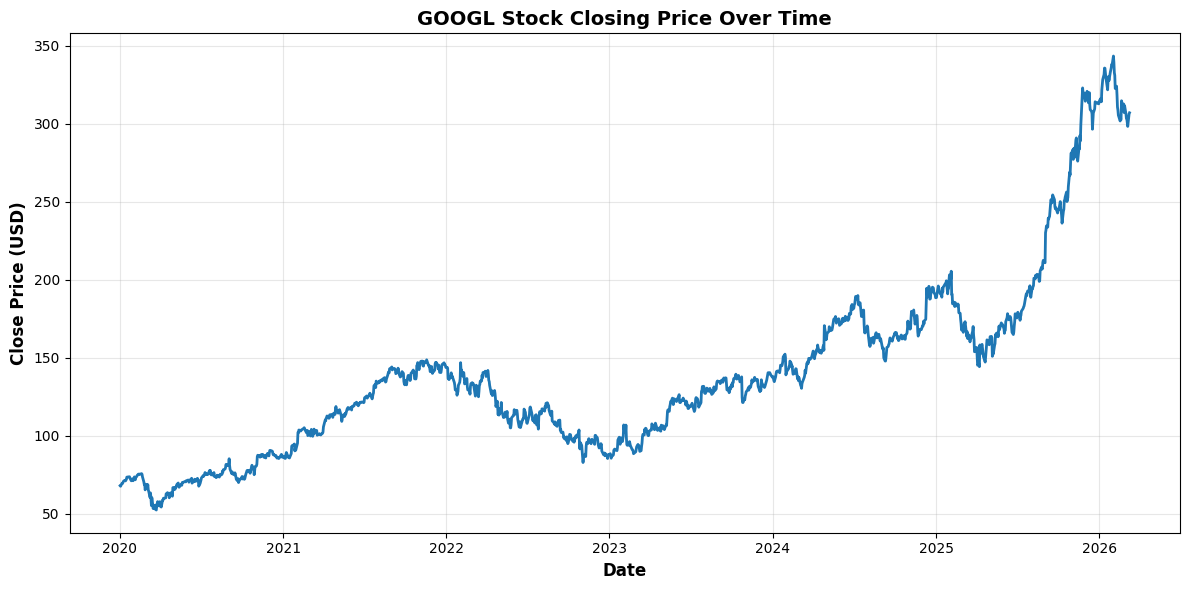

In [85]:
# Plot Closing Price Over Time

plt.figure(figsize=(12,6))
plt.plot(stock_df['Date'], stock_df['Close'], linewidth=2, color='#1f77b4')
plt.title(f'{ticker_symbol} Stock Closing Price Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Close Price (USD)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

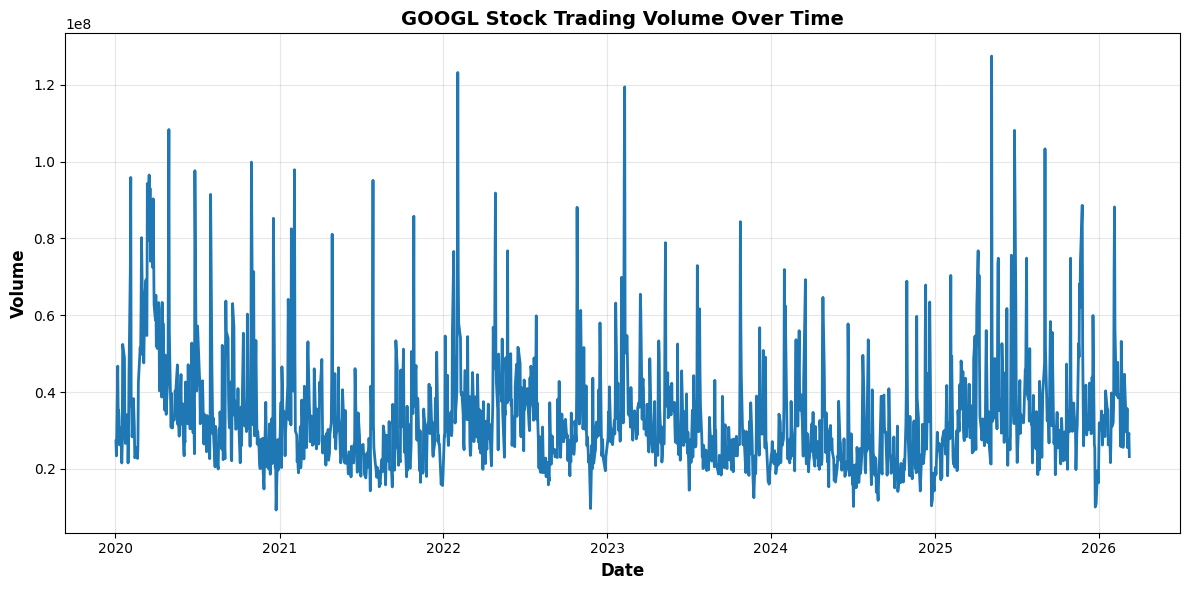

In [86]:
# Plot Trading Volume Over Time

plt.figure(figsize=(12,6))
plt.plot(stock_df['Date'], stock_df['Volume'], linewidth=2, color='#1f77b4')
plt.title(f'{ticker_symbol} Stock Trading Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Volume', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data Preprocessing and Feature Engineering

In [87]:
# Select target column for prediction
target_column = 'Close'
price_values = stock_df[target_column].values.reshape(-1,1)

# Initialize MinMaxScaler for normalization
normalizer = MinMaxScaler(feature_range=(0,1))
normalized_prices = normalizer.fit_transform(price_values)

print(f"Original Price Range: {price_values.min():.2f} to {price_values.max():.2f}")
print(f"Normalized Price Range: {normalized_prices.min():.2f} to {normalized_prices.max():.2f}")

Original Price Range: 52.27 to 343.45
Normalized Price Range: 0.00 to 1.00


In [88]:
# Create sequences for LSTM input
def build_sequences(data_array, lookback_window):
    feature_sequences = []
    target_values = []

    for idx in range(lookback_window, len(data_array)):
        feature_sequences.append(data_array[idx - lookback_window:idx, 0])
        target_values.append(data_array[idx, 0])
    return np.array(feature_sequences), np.array(target_values)

# Define lookback window (Number of Previous days to use for prediction)
lookback_period = 60

# Generate sequences
sequence_features, sequence_targets = build_sequences(normalized_prices, lookback_period)

print(f"Feature Sequences Shape: {sequence_features.shape}")
print(f"Target Sequence Shape: {sequence_targets.shape}")




Feature Sequences Shape: (1494, 60)
Target Sequence Shape: (1494,)


In [89]:
# Reshape features for LSTM input (sample, time steps, features)
sequence_features = np.reshape(sequence_features, (sequence_features.shape[0], sequence_features.shape[1], 1))
print(f"Reshaped features for LSTM: {sequence_features.shape}")

Reshaped features for LSTM: (1494, 60, 1)


## Train-Test Split

In [90]:
# Split Data into 80% training set and 20% test set
split_ratio = 0.8
split_index = int(len(sequence_features) * split_ratio)

features_train = sequence_features[:split_index]
targets_train = sequence_targets[:split_index]

features_test = sequence_features[split_index:]
targets_test = sequence_targets[split_index:]

print(f"Training Set Size: {len(features_train)}")
print(f"Testing Set Size: {len(features_test)}")
print(f"Training Features Shape: {features_train.shape}")
print(f"Testing Features Shape: {features_test.shape}")

Training Set Size: 1195
Testing Set Size: 299
Training Features Shape: (1195, 60, 1)
Testing Features Shape: (299, 60, 1)


## Build LSTM Model Architecture

In [91]:
# Build LSTM neural network
lstm_model = Sequential()

# First LSTM model with return sequences
lstm_model.add(LSTM(
    units = 50,
    return_sequences = True,
    input_shape=(features_train.shape[1], 1)
))
lstm_model.add(Dropout(0.2))

# Second LSTM layer
lstm_model.add(LSTM(units = 50, return_sequences = True))
lstm_model.add(Dropout(0.2))

# Third LSTM layer
lstm_model.add(LSTM(units = 50, return_sequences = False))
lstm_model.add(Dropout(0.2))

# Output Layer
lstm_model.add(Dense(units=1))

# Compile the Model
lstm_model.compile(optimizer='adam',loss = 'mean_squared_error' )

# Display Model Architecture
lstm_model.summary()

/Users/anamleen/miniforge3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
from tensorflow.keras.callbacks import EarlyStopping


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


training_history = lstm_model.fit(
    features_train, 
    targets_train, 
    epochs=50, 
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 226ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 8.5329e-04 - val_loss: 0.0014
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 8.4009e-04 - val_loss: 0.0014
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 7.9095e-04 - val_loss: 9.0019e-04
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 7.4532e-04 - val_loss: 0.0011
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.7256e-04 - val_loss: 9.5281e-04
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.6045e-04 - val_loss: 9.2403e-04
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.4003e-04 - val_loss: 0.0013
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 7.1860e-04 - val_loss: 9.3530e-04
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.9596e-04 - val_loss: 8.3768e-04
Epoch

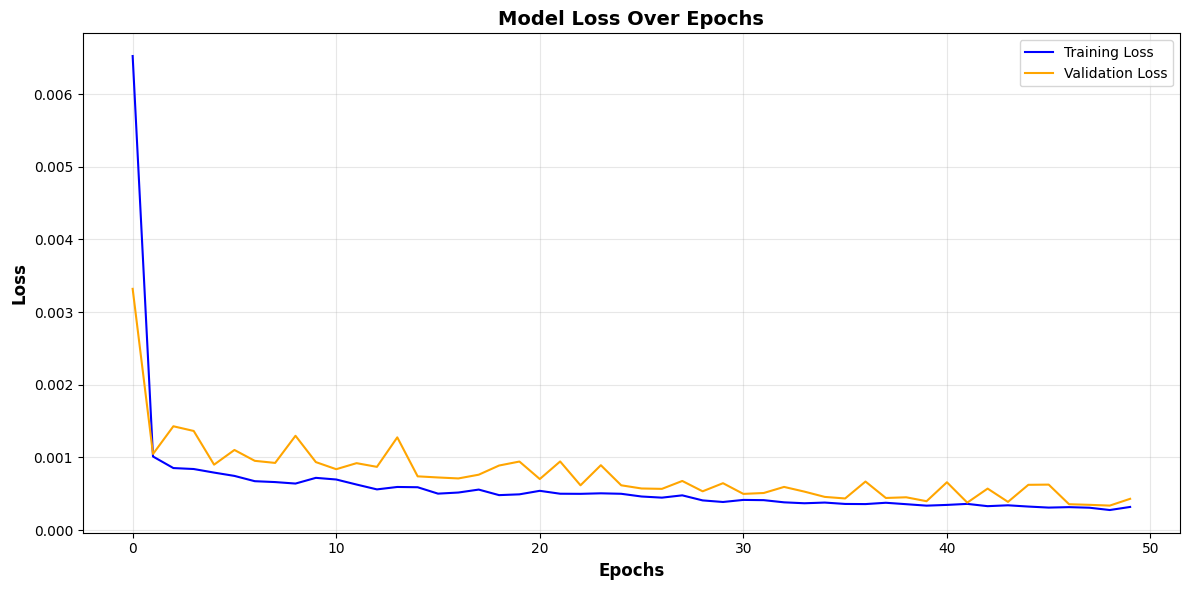

In [93]:
# Plot training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss', color='blue')
plt.plot(training_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model Predictions and Evaluation


In [94]:
# Generate predictions on the test set
predicted_prices = lstm_model.predict(features_test)

# Inverse transform the predicted and actual prices to original scale
predicted_prices_scaled = normalizer.inverse_transform(predicted_prices)
actual_prices_scaled = normalizer.inverse_transform(targets_test.reshape(-1, 1))

print(f"Predicted Shape: {predicted_prices_scaled.shape}")
print(f"Actual Values Shape:{actual_prices_scaled.shape}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step
Predicted Shape: (299, 1)
Actual Values Shape:(299, 1)


In [95]:
# Calculate evaluation metrics
mse = mean_squared_error(actual_prices_scaled, predicted_prices_scaled)
mae = mean_absolute_error(actual_prices_scaled, predicted_prices_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(actual_prices_scaled, predicted_prices_scaled)    

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print("=" * 50)

MODEL PERFORMANCE METRICS
Mean Squared Error (MSE): 103.9986
Root Mean Squared Error (RMSE): 10.1980
Mean Absolute Error (MAE): 7.6193
R-squared (R²): 0.9726


## Visualize Actual vs Predicted Values

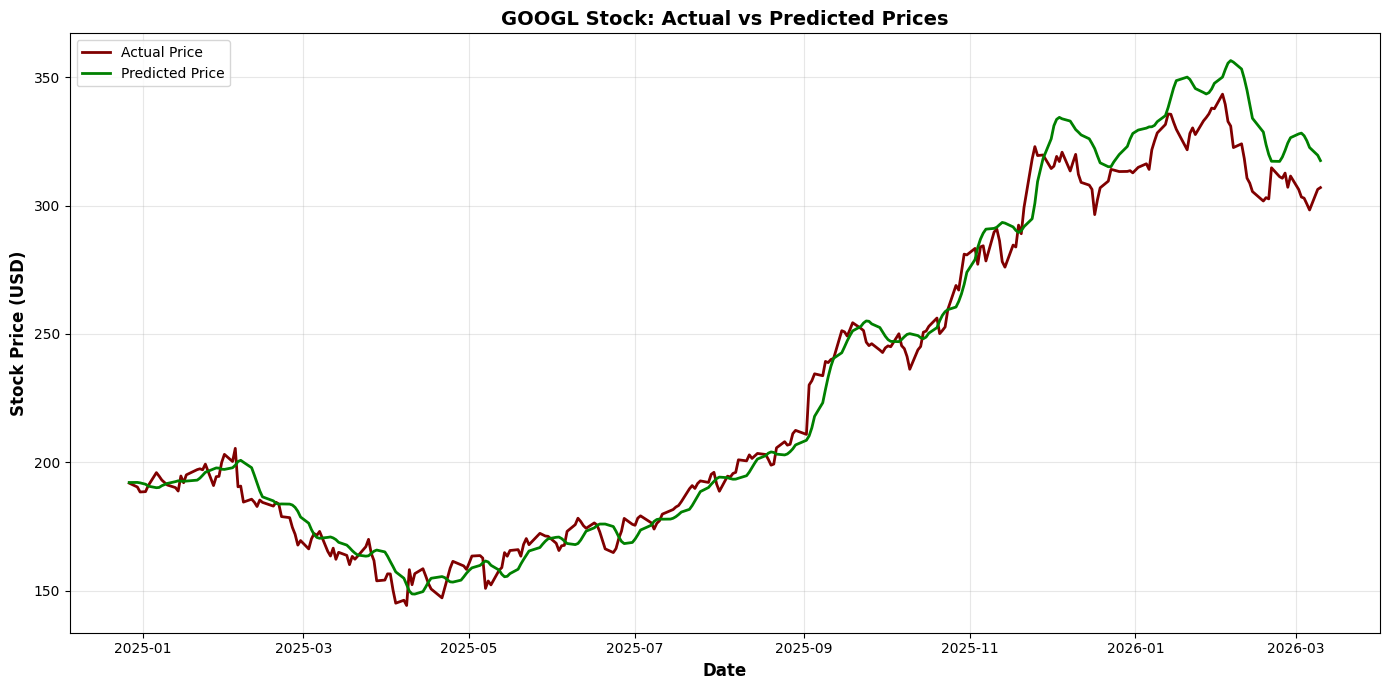

In [96]:
# Prepare data for plotting
test_dates = stock_df['Date'][split_index + lookback_period:].reset_index(drop=True)
plot_dates = test_dates[-len(predicted_prices):]

# create comparison plot of actual vs predicted prices
plt.figure(figsize=(14, 7))

# Add actual price line
plt.plot(plot_dates, actual_prices_scaled.flatten(), color='maroon', label='Actual Price',linewidth = 2)

# Add predicted price line
plt.plot(plot_dates, predicted_prices_scaled.flatten(), color='green', label='Predicted Price', linewidth = 2)

plt.title(f"{ticker_symbol} Stock: Actual vs Predicted Prices", fontsize=14, fontweight='bold')

plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.ylabel("Stock Price (USD)", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lstm_model.save('lstm_stock_prediction_model.keras')


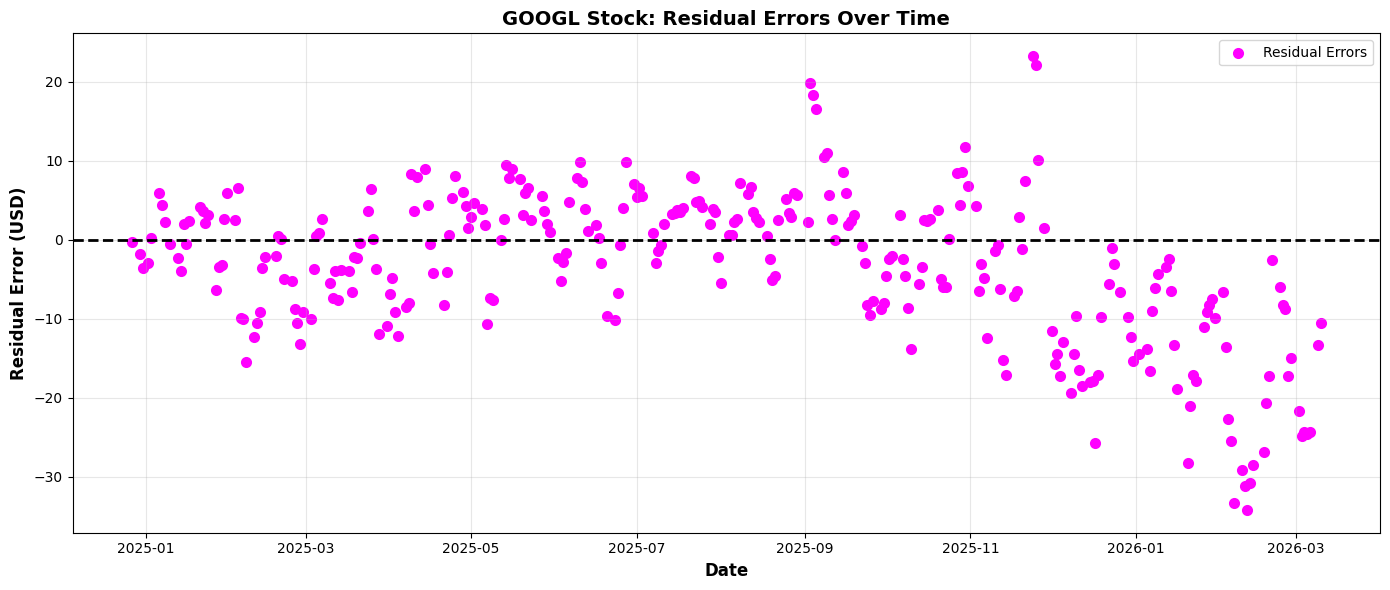

In [97]:
# Calculate and plot prediction erroors
residual_errors = actual_prices_scaled.flatten() - predicted_prices_scaled.flatten()

# Plot residual errors
plt.figure(figsize=(14, 6))
plt.scatter(plot_dates, residual_errors, color='magenta', label='Residual Errors', linewidth=2)

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

plt.title(f"{ticker_symbol} Stock: Residual Errors Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.ylabel("Residual Error (USD)", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
%pip install bayesian-optimization

Note: you may need to restart the kernel to use updated packages.


In [99]:
# Install if needed
# pip install bayesian-optimization

from bayes_opt import BayesianOptimization
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# ── Fast evaluation function ────────────────────────────────────────────────
def lstm_eval(units, dropout, batch_size_exp, lr):
    """Train a lightweight LSTM and return negative val-loss (to maximize)."""
    units      = int(round(units))
    batch_size = int(2 ** round(batch_size_exp))   # e.g. 2^5=32, 2^6=64
    dropout    = float(dropout)
    lr         = float(lr)

    # Use training data for speed
    n_fast = int(len(features_train) * 1.0)
    X_fast = features_train[:n_fast]
    y_fast = targets_train[:n_fast]

    tf.keras.backend.clear_session()
    m = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(features_train.shape[1], 1)),
        Dropout(dropout),
        LSTM(units, return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    hist = m.fit(
        X_fast, y_fast,
        epochs=50,                # low epoch cap for fast eval
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=[es],
        verbose=0
    )
    val_loss = min(hist.history['val_loss'])
    return -val_loss              # BayesOpt maximises, so negate loss

# ── Search space ────────────────────────────────────────────────────────────
pbounds = {
    'units':          (32, 128),   # LSTM units per layer
    'dropout':        (0.1, 0.4),  # dropout rate
    'batch_size_exp': (4, 7),      # 2^4=16 … 2^7=128
    'lr':             (1e-4, 1e-2) # learning rate
}

# ── Run optimiser ────────────────────────────────────────────────────────────
optimizer = BayesianOptimization(
    f=lstm_eval,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=3,   # random exploration rounds
    n_iter=7         # Bayesian rounds  →  10 evals total (~fast)
)

best = optimizer.max['params']
print("\n✅ Best params found:", best)


|   iter    |  target   |   units   |  dropout  | batch_... |    lr     |
-------------------------------------------------------------------------


/Users/anamleen/miniforge3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 1         | -0.000456 | 67.955851 | 0.3852142 | 6.1959818 | 0.0060267 |
| 2         | -0.000249 | 46.977789 | 0.1467983 | 4.1742508 | 0.0086751 |
| 3         | -0.000163 | 89.707041 | 0.3124217 | 4.0617534 | 0.0097021 |


/Users/anamleen/miniforge3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 4         | -0.000376 | 90.303144 | 0.2845153 | 5.2069335 | 0.0099275 |


...

| 8         | -0.000184 | 89.784965 | 0.2556507 | 4.1152846 | 0.01      |


/Users/anamleen/miniforge3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 9         | -0.000263 | 89.687709 | 0.3115908 | 4.1971005 | 0.01      |


/Users/anamleen/miniforge3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 10        | -0.000332 | 89.722271 | 0.1925383 | 4.0152658 | 0.01      |

✅ Best params found: {'units': 89.70704112734805, 'dropout': 0.3124217733388137, 'batch_size_exp': 4.061753482887408, 'lr': 0.009702107536403744}


In [100]:
from tensorflow.keras.callbacks import ReduceLROnPlateau# ── Rebuild and train full model with best hyperparameters ──────────────────
best_units      = int(round(best['units']))
best_dropout    = float(best['dropout'])
best_batch_size = int(2 ** round(best['batch_size_exp']))
best_lr         = float(best['lr'])

print(f"Training final model  →  units={best_units}, dropout={best_dropout:.2f}, "
      f"batch={best_batch_size}, lr={best_lr:.5f}")

tf.keras.backend.clear_session()
lstm_model = Sequential([
    LSTM(best_units, return_sequences=True,
         input_shape=(features_train.shape[1], 1)),
    Dropout(best_dropout),
    LSTM(best_units, return_sequences=True),
    Dropout(best_dropout),
    LSTM(best_units, return_sequences=False),
    Dropout(best_dropout),
    Dense(1)
])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(best_lr),
    loss='mse'
)
lstm_model.summary()

# ReduceLROnPlateau decays LR when stuck, but never stops training early.
# This lets the model run all 50 epochs and recover from plateaus naturally.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # halve the LR when stuck
    patience=5,       # wait 5 epochs before reducing
    min_lr=1e-6,
    verbose=1
)

training_history = lstm_model.fit(
    features_train, targets_train,
    epochs=50,
    batch_size=best_batch_size,
    validation_split=0.15,
    callbacks=[reduce_lr],   # no EarlyStopping → always runs all 50 epochs
    verbose=1
)


Training final model  →  units=90, dropout=0.31, batch=16, lr=0.00970


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 90)         │        33,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 90)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 90)         │        65,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 90)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 90)             │        65,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,531 (638.79 KB)

 Trainable params: 163,531 (638.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - loss: 0.0076 - val_loss: 0.0029 - learning_rate: 0.0097
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 9.4382e-04 - val_loss: 6.3934e-04 - learning_rate: 0.0097
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 6.1544e-04 - val_loss: 7.9518e-04 - learning_rate: 0.0097
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 6.1521e-04 - val_loss: 0.0014 - learning_rate: 0.0097
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.8657e-04 - val_loss: 5.6215e-04 - learning_rate: 0.0097
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 4.5038e-04 - val_loss: 7.6032e-04 - learning_rate: 0.0097
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 4.6260e-04 - val_loss: 5.0917e-04 - learning_rate: 0.0097
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.5206e-04 - val_loss: 6.4846e-04 - learning_rate: 0.0097
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 5.0518e-04 - va

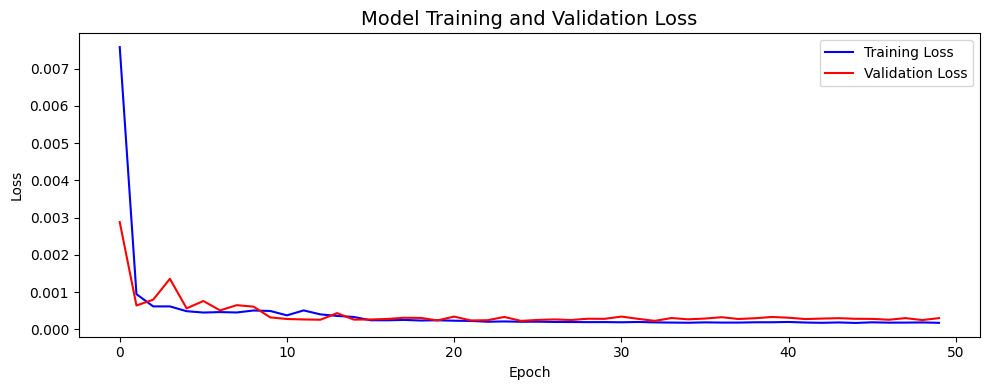

In [101]:
# Plot training and validation loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(training_history.history['loss'], color='blue', label='Training Loss')
ax.plot(training_history.history['val_loss'], color='red', label='Validation Loss')
ax.set_title('Model Training and Validation Loss', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()


In [102]:
# Generate predictions on test data
predicted_values = lstm_model.predict(features_test)

# Inverse transform to get actual price scale
predicted_prices = normalizer.inverse_transform(predicted_values)
actual_prices = normalizer.inverse_transform(targets_test.reshape(-1, 1))

print(f"Predictions shape: {predicted_prices.shape}")
print(f"Actual values shape: {actual_prices.shape}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step
Predictions shape: (299, 1)
Actual values shape: (299, 1)


In [103]:
# Calculate performance metrics
mse_score = mean_squared_error(actual_prices, predicted_prices)
rmse_score = np.sqrt(mse_score)
mae_score = mean_absolute_error(actual_prices, predicted_prices)
r2_metric = r2_score(actual_prices, predicted_prices)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse_score:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_score:.4f}")
print(f"Mean Absolute Error (MAE): {mae_score:.4f}")
print(f"R-squared (R²): {r2_metric:.4f}")
print("=" * 50)

MODEL PERFORMANCE METRICS
Mean Squared Error (MSE): 165.0637
Root Mean Squared Error (RMSE): 12.8477
Mean Absolute Error (MAE): 10.0894
R-squared (R²): 0.9565


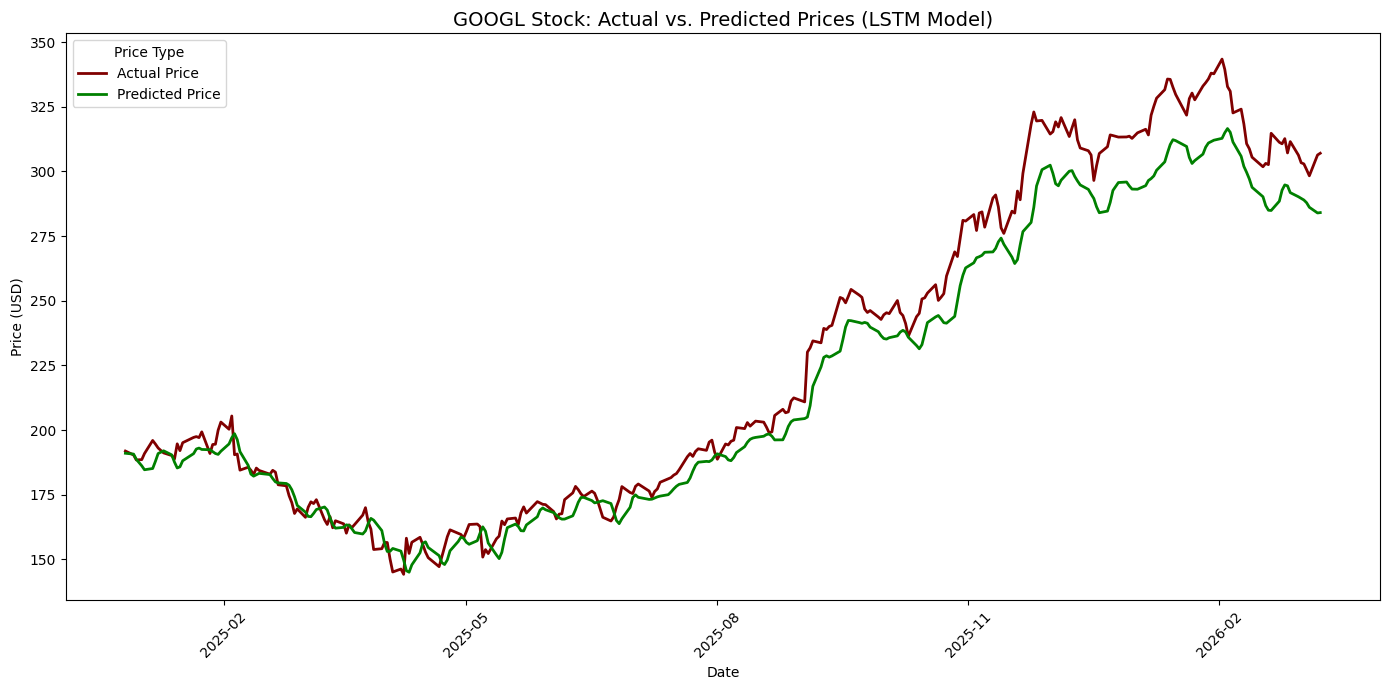

In [104]:
# Prepare dates for plotting
test_dates = stock_df['Date'][lookback_period + split_index:].reset_index(drop=True)
plot_dates = test_dates[-len(predicted_prices):]

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(plot_dates, actual_prices.flatten(), color='maroon', linewidth=2, label='Actual Price')
ax.plot(plot_dates, predicted_prices.flatten(), color='green', linewidth=2,
        linestyle='-', label='Predicted Price')
ax.set_title(f'{ticker_symbol} Stock: Actual vs. Predicted Prices (LSTM Model)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(title='Price Type')
plt.tight_layout()
plt.show()
